In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("files/penguins.csv")
df.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
df.shape


(344, 9)

In [4]:
df.columns

Index(['Unnamed: 0', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [6]:
df.isnull().sum()

Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [7]:
df['year'] = pd.to_datetime(df['year'], format='%Y')
df['year'].head()

0   2007-01-01
1   2007-01-01
2   2007-01-01
3   2007-01-01
4   2007-01-01
Name: year, dtype: datetime64[ns]

In [8]:
numeric_df=df.select_dtypes(include=["int64","float64"])
numeric_cols=numeric_df.columns
print(numeric_cols)

Index(['Unnamed: 0', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g'],
      dtype='object')


In [9]:
string_df=df.select_dtypes(include="object")
string_cols=string_df.columns
print(string_cols)

Index(['species', 'island', 'sex'], dtype='object')


In [10]:
df[numeric_cols]=df[numeric_cols].fillna(numeric_df.median())
df[string_cols]=df[string_cols].fillna("Unknown")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         344 non-null    int64         
 1   species            344 non-null    object        
 2   island             344 non-null    object        
 3   bill_length_mm     344 non-null    float64       
 4   bill_depth_mm      344 non-null    float64       
 5   flipper_length_mm  344 non-null    float64       
 6   body_mass_g        344 non-null    float64       
 7   sex                344 non-null    object        
 8   year               344 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 24.3+ KB


In [12]:
corr_matrix=numeric_df.corr()
print(corr_matrix)

                   Unnamed: 0  bill_length_mm  bill_depth_mm  \
Unnamed: 0           1.000000        0.766039      -0.259563   
bill_length_mm       0.766039        1.000000      -0.235053   
bill_depth_mm       -0.259563       -0.235053       1.000000   
flipper_length_mm    0.455372        0.656181      -0.583851   
body_mass_g          0.275493        0.595110      -0.471916   

                   flipper_length_mm  body_mass_g  
Unnamed: 0                  0.455372     0.275493  
bill_length_mm              0.656181     0.595110  
bill_depth_mm              -0.583851    -0.471916  
flipper_length_mm           1.000000     0.871202  
body_mass_g                 0.871202     1.000000  


In [13]:
exclude_feature=['Unnamed:0']
final_features=[col for col in numeric_cols if col.replace(" ","") not in exclude_feature]
print(final_features)

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [14]:
final_numeric_df=df[final_features]
corr_matrix=final_numeric_df.corr()

<Axes: >

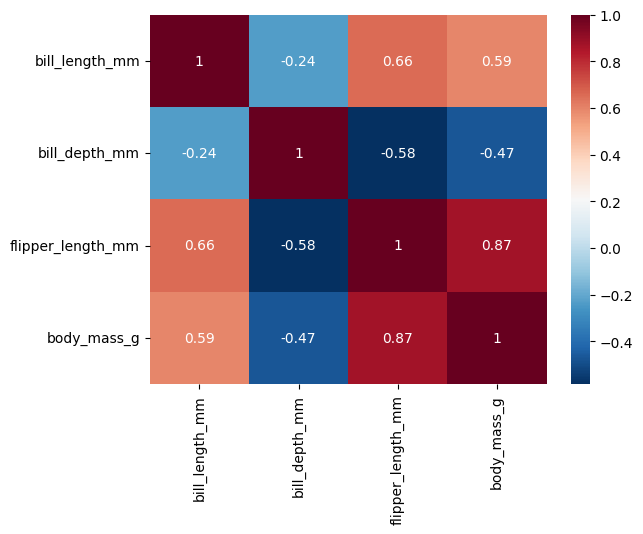

In [15]:
sns.heatmap(corr_matrix,annot=True,cmap="RdBu_r")

In [16]:
final_numeric_df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,43.925000,17.152035,200.892442,4200.872093
std,5.443792,1.969060,14.023826,799.696532
min,32.100000,13.100000,172.000000,2700.000000
25%,39.275000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [17]:
from sklearn.preprocessing import RobustScaler

In [18]:
scaler = RobustScaler()

df[final_features] = scaler.fit_transform(df[final_features])

In [19]:
df[final_features].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,-0.056911,-0.047731,0.169237,0.125727
std,0.590113,0.635181,0.609732,0.666414
min,-1.338753,-1.354839,-1.086957,-1.125000
25%,-0.560976,-0.548387,-0.304348,-0.416667
50%,0.000000,0.000000,0.000000,0.000000
75%,0.439024,0.451613,0.695652,0.583333
max,1.642276,1.354839,1.478261,1.875000


In [20]:
X=df[final_features].values

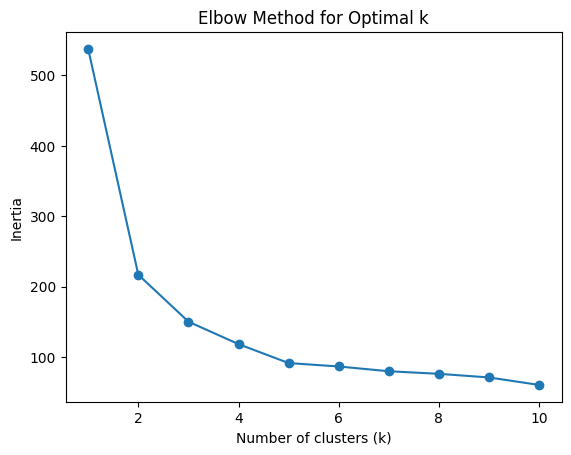

In [21]:

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()
#Inertia is sum of squared distance between each point and its cluster centroid?
# Lower inertia: points are closer to the cluster center, meaning better clustering

In [22]:
k=2

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

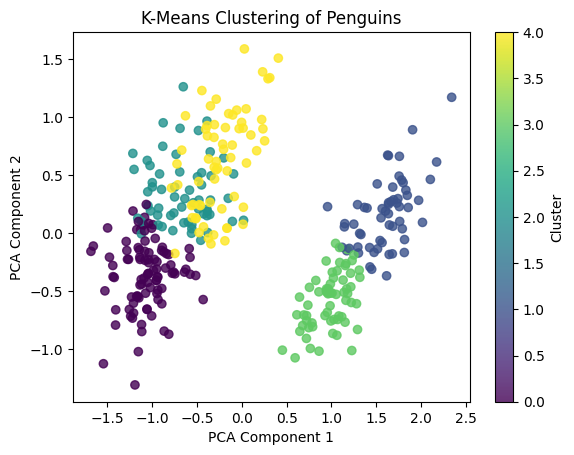

In [25]:

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.8
)

plt.title("K-Means Clustering of Penguins")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")

plt.show()

In [26]:
pd.crosstab(df['species'], df['cluster'])

cluster,0,1,2,3,4
species,,,,,
Adelie,89,0,60,0,3
Chinstrap,7,0,0,0,61
Gentoo,0,58,0,65,1


In [27]:
# Adelie and Chinstrap overlap in feature space
# Gentoo is clearly separated

In [28]:
# PCA was used to project the clustered data into two dimensions for visualization. The plot shows three distinct clusters, where one cluster is clearly separated, while the other two show partial overlap. This indicates that the algorithm successfully identified underlying groupings, with overlap reflecting similarity between certain species.

In [29]:
# k = 3 captures maximum structure

# k = 2 would collapse the left side into one blob

In [30]:
#Heavier penalty
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# results = []

# for k in range(2, 8):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(X)

#     inertia = kmeans.inertia_
#     silhouette = silhouette_score(X, labels)

#     results.append((k, inertia, silhouette))

# best_k = None
# best_score = -1

# for k, inertia, silhouette in results:
#     score = silhouette - 0.05 * (k - 2)

#     print(f"k={k}, silhouette={silhouette:.3f}, penalized_score={score:.3f}")

#     if score > best_score:
#         best_score = score
#         best_k = k

# print(f"\nChosen k after penalty: {best_k}")


In [31]:
#trying with k=3
kmeans_2=KMeans(n_clusters=3,random_state=42)
clusters_2=kmeans_2.fit_predict(X)

df['cluster2']=clusters_2


In [32]:
#PCA REDUCTION 
pca_2=PCA(n_components=3)
X_pca_2=pca_2.fit_transform(X)

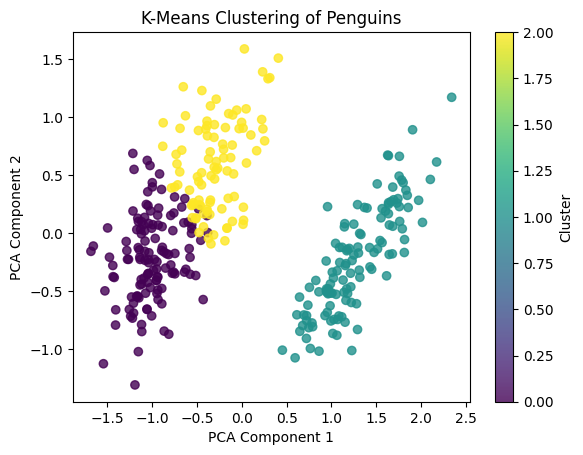

In [33]:
scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=clusters_2,
    cmap="viridis",
    alpha=0.8
)

plt.title("K-Means Clustering of Penguins")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")

plt.show()

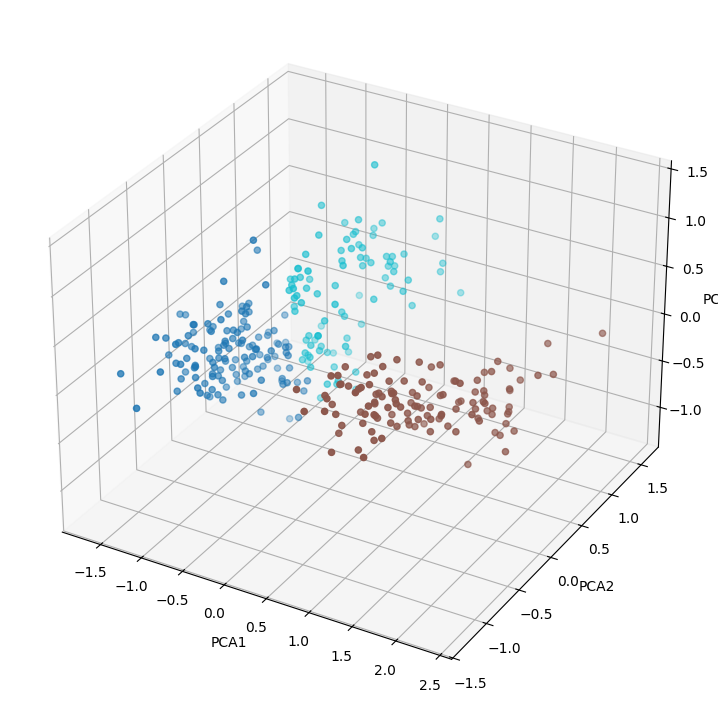

In [34]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    X_pca_2[:, 2],
    c=clusters_2,
    cmap='tab10'
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

plt.show()

In [35]:
pd.crosstab(df['species'], df['cluster2'])

cluster2,0,1,2
species,,,
Adelie,122,0,30
Chinstrap,8,0,60
Gentoo,0,123,1


In [ ]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# results = []

# for k in range(2, 8):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(X)

#     inertia = kmeans.inertia_
#     silhouette = silhouette_score(X, labels)

#     results.append((k, inertia, silhouette))

# best_k = None
# best_score = -1

# for k, inertia, silhouette in results:
#     score = silhouette / k

#     print(f"k={k}, silhouette={silhouette:.3f}, penalized_score={score:.3f}")

#     if score > best_score:
#         best_score = score
#         best_k = k

# print(f"\nChosen k after penalty: {best_k}")

: 